## 12. Double Machine Learning (DML) — Causal Effect of Food Affordability

**Self-contained notebook** — loads directly from saved CSVs, no need to re-run prior notebooks.

| Input file | Purpose |
|---|---|
| `final_spatial_ml_dataset.csv` | County-level features and outcomes |

**Goal:** Estimate the causal effect of 5 food affordability treatments — Cost Per Meal,
SNAP Participation Rate, Median Household Income, Households with No Vehicle,
and SNAP Below Poverty Gap — on obesity rate, diabetes rate,
and Medicare cost per capita, while controlling for all observed confounders
(socioeconomic controls, spatial lags, AE embeddings).

**Method:** LinearDML (EconML) with XGBoost nuisance models.

**Output:**
1. `master_dml_5_treatments.csv` — ATE, 95% CI, and significance for all 15 treatment–outcome pairs
2. `all_county_causal_effects.csv` — Per-county heterogeneous effects for mapping
3. `final_policy_ranking.csv` — Significant causal levers ranked by effect size


### 12.0 Imports

In [3]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'econml', '--quiet'],
    capture_output=True, text=True
)
print(result.stdout[-2000:] if result.stdout else "no stdout")
print(result.stderr[-2000:] if result.stderr else "no stderr")

no stdout
no stderr


In [4]:
from econml.dml import LinearDML
print("works")

works


In [5]:
import subprocess, sys

try:
    import econml
    print(f'econml {econml.__version__} already installed')
except ImportError:
    print('Installing econml...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'econml'])
    print('Done')

econml 0.16.0 already installed


In [6]:
import subprocess
result = subprocess.run(
    ['conda', 'install', '-y', '-n', 'python3', 'xgboost', '-c', 'conda-forge'],
    capture_output=True, text=True
)
print(result.stdout[-3000:])
print(result.stderr[-3000:])

Retrieving notices: done


EnvironmentLocationNotFound: Not a conda environment: C:\Users\Arul\anaconda3\envs\python3




In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from econml.dml import LinearDML

print(f'numpy  : {np.__version__}')
print(f'pandas : {pd.__version__}')
import econml
print(f'econml : {econml.__version__}')
print('✅ All imports OK')

numpy  : 1.26.4
pandas : 2.2.2
econml : 0.16.0
✅ All imports OK


### 12.1 Configuration

In [9]:
# ── File path ────────────────────────────────────────────────────
DATA_PATH = 'final_spatial_ml_dataset.csv'

# ── Treatment variable ───────────────────────────────────────────
TREATMENT = 'Cost Per Meal'   # T: the variable whose causal effect we estimate

# ── Outcome variables ────────────────────────────────────────────
OUTCOMES = {
    'obesity_rate':            'Obesity Rate (%)',
    'diabetes_rate':           'Diabetes Rate (%)',
    'TOT_MDCR_STDZD_PYMT_PC': 'Medicare Cost Per Capita ($)',
}

# ── AE embeddings ────────────────────────────────────────────────
AE_FEATURES = ['AE3d_latent1', 'AE3d_latent2', 'AE3d_latent3']

# ── Spatial lags ─────────────────────────────────────────────────
SPATIAL_FEATURES = ['WX_AE_1', 'WX_AE_2', 'WX_AE_3']

# ── Socioeconomic controls ────────────────────────────────────────
CONTROL_FEATURES = [
    'min_wage_2023',
    'poverty_rate',
    'population_density',
    'Median_Household_Income',
    'percent_65_plus',
]

# ── Confounder sets ───────────────────────────────────────────────
# With embeddings
X_WITH_EMBED = AE_FEATURES + SPATIAL_FEATURES + CONTROL_FEATURES

print('✅ Configuration loaded')
print(f'   Treatments          : 5 (Cost Per Meal, SNAP, Income, No Vehicle, SNAP Gap)')
print(f'   Outcomes            : {list(OUTCOMES.values())}')
print(f'   X (with embeddings) : {len(X_WITH_EMBED)} features')


✅ Configuration loaded
   Treatments          : 5 (Cost Per Meal, SNAP, Income, No Vehicle, SNAP Gap)
   Outcomes            : ['Obesity Rate (%)', 'Diabetes Rate (%)', 'Medicare Cost Per Capita ($)']
   X (with embeddings) : 11 features


### 12.2 Load & validate data

In [11]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Check treatment column
if TREATMENT not in df.columns:
    raise ValueError(f"Treatment column '{TREATMENT}' not found. "
                     f"Available columns: {[c for c in df.columns if 'meal' in c.lower() or 'cost' in c.lower()]}")
else:
    print(f'✅ Treatment column found: {TREATMENT}')
    print(f'   Range: [{df[TREATMENT].min():.2f}, {df[TREATMENT].max():.2f}]')
    print(f'   Mean : {df[TREATMENT].mean():.2f}  |  Std: {df[TREATMENT].std():.2f}')

# Check all feature columns — 5 treatments only
all_treatments = [
    'Cost Per Meal', 'SNAP_Participation_Rate_Pct', 'Median_Household_Income',
    'pct_households_no_vehicle', 'No_SNAP_Below_Poverty_Gap'
]
# BUG FIX: use all_cols (not all_needed) so cell 12.4 can reference it
all_cols = list(set(X_WITH_EMBED + list(OUTCOMES.keys()) + all_treatments))
missing = [c for c in all_cols if c not in df.columns]
if missing:
    print(f'\n⚠️  Missing columns (will be skipped): {missing}')
    X_WITH_EMBED = [c for c in X_WITH_EMBED if c in df.columns]
else:
    print('✅ All feature columns found')


Dataset: 2,226 rows × 69 columns
✅ Treatment column found: Cost Per Meal
   Range: [2.64, 6.09]
   Mean : 3.61  |  Std: 0.36
✅ All feature columns found


In [12]:
### 12.2b Winsorize extreme outliers in treatment variables

# pct_households_no_vehicle has structural outliers (remote AK/HI counties
# with no road access, e.g. Nome Census Area ~0.56) that are real but
# unrepresentative of policy-relevant counties. Winsorize at 99th percentile
# so those counties stay in the dataset but don't distort DML nuisance models.

treatments_to_winsorize = ['pct_households_no_vehicle']

for col in treatments_to_winsorize:
    if col in df.columns:
        p99 = df[col].quantile(0.99)
        n_clipped = (df[col] > p99).sum()
        df[col] = df[col].clip(upper=p99)
        print(f"Winsorized '{col}': clipped {n_clipped} counties at p99 ceiling = {p99:.4f}")

print("✅ Winsorization complete — df is ready for df_clean creation in 12.4")

Winsorized 'pct_households_no_vehicle': clipped 23 counties at p99 ceiling = 0.1841
✅ Winsorization complete — df is ready for df_clean creation in 12.4


### 12.3 DML estimation function

In [14]:
def run_dml(Y_vals, T_vals, X_vals, label=''):
    """
    Fit LinearDML and return ATE + inference summary.

    Parameters
    ----------
    Y_vals : array-like  — outcome
    T_vals : array-like  — treatment variable (any of the 5 treatments)
    X_vals : DataFrame   — confounders
    label  : str         — label for printing

    Returns
    -------
    dict with ATE, std, CI, per-county effects array, and the fitted estimator
    """
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(X_vals)

    model_y = XGBRegressor(n_estimators=100, max_depth=5,
                           random_state=42, verbosity=0)
    model_t = XGBRegressor(n_estimators=100, max_depth=5,
                           random_state=42, verbosity=0)

    est = LinearDML(
        model_y           = model_y,
        model_t           = model_t,
        discrete_treatment= False,
        random_state      = 42,
        cv                = 5,        # 5-fold cross-fitting
    )
    est.fit(Y_vals, T_vals, X=X_sc)

    # Per-county heterogeneous treatment effects
    # effect(X_sc) returns one value per county, varying with each county's
    # confounder profile — this is the correct call for heterogeneous effects.
    effects = est.effect(X_sc)   # shape: (n_counties,)
    ate     = effects.mean()     # Average Treatment Effect
    std     = effects.std()      # Spread across counties

    # Inference on ATE
    inf  = est.ate_inference(X=X_sc)
    ci   = inf.conf_int_mean()   # 95% CI

    if label:
        print(f'  {label}')
        print(f'    ATE : {ate:.4f}  (std: {std:.4f})')
        print(f'    95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]')
        significant = not (ci[0] < 0 < ci[1])
        print(f'    Significant (CI excludes 0): {significant}')

    return {
        'ate':       ate,
        'std':       std,
        'ci_low':    ci[0],
        'ci_high':   ci[1],
        'effects':   effects,   # (n_counties,) array — heterogeneous per-county effects
        'estimator': est,
        'label':     label,
    }


### 12.4 Run DML across all treatments and outcomes

In [16]:
all_cols = list(set(
    X_WITH_EMBED +
    list(OUTCOMES.keys()) +
    ['Cost Per Meal', 'SNAP_Participation_Rate_Pct', 'Median_Household_Income',
     'pct_households_no_vehicle', 'No_SNAP_Below_Poverty_Gap']
))

df_clean = df.dropna(subset=[c for c in all_cols if c in df.columns]).reset_index(drop=True)
print(f"Clean dataset: {df_clean.shape[0]:,} rows (dropped {df.shape[0] - df_clean.shape[0]} with NaNs)")

all_results = []
results = {}

county_effects_df = df_clean[['FIPS', 'State', 'County']].copy()

# 5 treatments only
treatments = [
    'Cost Per Meal',
    'SNAP_Participation_Rate_Pct',
    'Median_Household_Income',
    'pct_households_no_vehicle',
    'No_SNAP_Below_Poverty_Gap',
]

outcomes = list(OUTCOMES.keys())

for t in treatments:
    results[t] = {}
    for o in outcomes:
        print(f"Processing: {t} -> {o}")

        res = run_dml(df_clean[o], df_clean[t], df_clean[X_WITH_EMBED],
                      label=f"{t} → {o}")

        all_results.append({
            'Treatment': t,
            'Outcome': OUTCOMES[o],
            'Model': 'DML + Embeddings',
            'ATE': res['ate'],
            'CI_Low': res['ci_low'],
            'CI_High': res['ci_high'],
            'Significant': 'YES' if (res['ci_low'] > 0 or res['ci_high'] < 0) else 'no'
        })

        results[t][o] = {
            'with_embed': res,
            'outcome_name': OUTCOMES[o],
        }

        # BUG FIX: use res['effects'] — the per-county array already returned by
        # FIXED: use res['effects'] (per-county array) not the scalar ATE.
        # scalar (the global ATE), causing every county to get the identical value.
        column_name = f"effect_{t.replace(' ', '_')}_on_{o.split('_')[0]}"
        county_effects_df[column_name] = res['effects']

pd.DataFrame(all_results).to_csv('master_dml_5_treatments.csv', index=False)
county_effects_df.to_csv('all_county_causal_effects.csv', index=False)

print("✅ Analysis Complete!")
print("Saved: 'master_dml_5_treatments.csv' (Summary)")
print("Saved: 'all_county_causal_effects.csv' (Per-County effects for all 5 treatments)")


Clean dataset: 2,168 rows (dropped 58 with NaNs)
Processing: Cost Per Meal -> obesity_rate
  Cost Per Meal → obesity_rate
    ATE : 0.8533  (std: 3.7655)
    95% CI: [-1.9335, 3.6400]
    Significant (CI excludes 0): False
Processing: Cost Per Meal -> diabetes_rate
  Cost Per Meal → diabetes_rate
    ATE : -1.7949  (std: 1.5186)
    95% CI: [-2.8857, -0.7041]
    Significant (CI excludes 0): True
Processing: Cost Per Meal -> TOT_MDCR_STDZD_PYMT_PC
  Cost Per Meal → TOT_MDCR_STDZD_PYMT_PC
    ATE : 47.5459  (std: 1933.3247)
    95% CI: [-1505.0611, 1600.1530]
    Significant (CI excludes 0): False
Processing: SNAP_Participation_Rate_Pct -> obesity_rate
  SNAP_Participation_Rate_Pct → obesity_rate
    ATE : 0.1191  (std: 0.0856)
    95% CI: [0.0740, 0.1641]
    Significant (CI excludes 0): True
Processing: SNAP_Participation_Rate_Pct -> diabetes_rate
  SNAP_Participation_Rate_Pct → diabetes_rate
    ATE : 0.0412  (std: 0.0518)
    95% CI: [0.0272, 0.0551]
    Significant (CI excludes 0):

### 12.5 Heterogeneous treatment effects

DML estimates a per-county effect, not just one average. This shows the
distribution of effects across all counties — are some counties affected
much more than others?

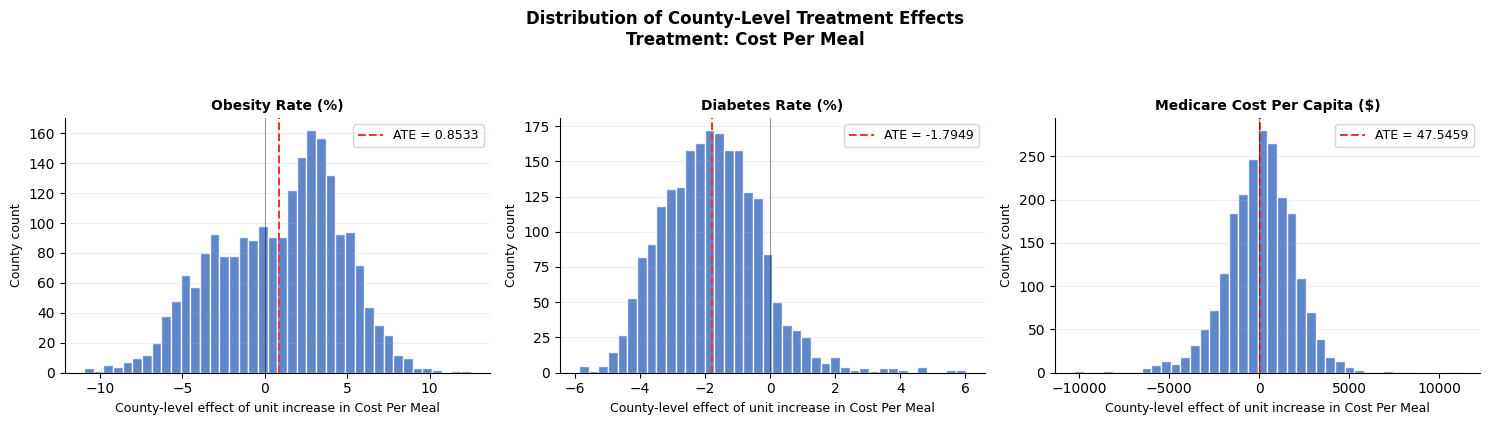

✅ Saved: dml_effect_distribution_Cost_Per_Meal.png


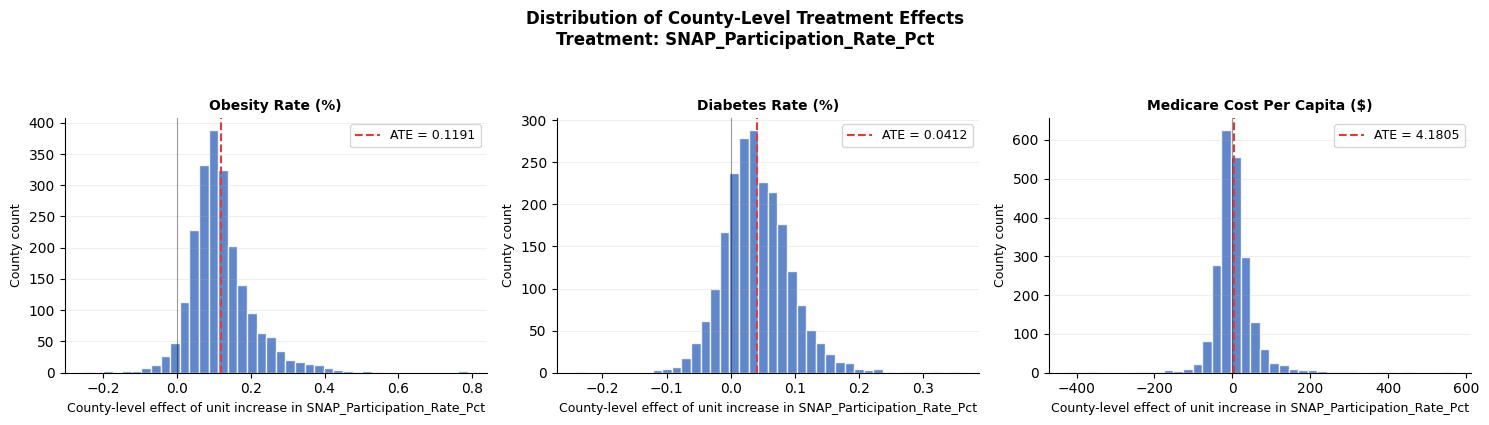

✅ Saved: dml_effect_distribution_SNAP_Participation_Rate_Pct.png


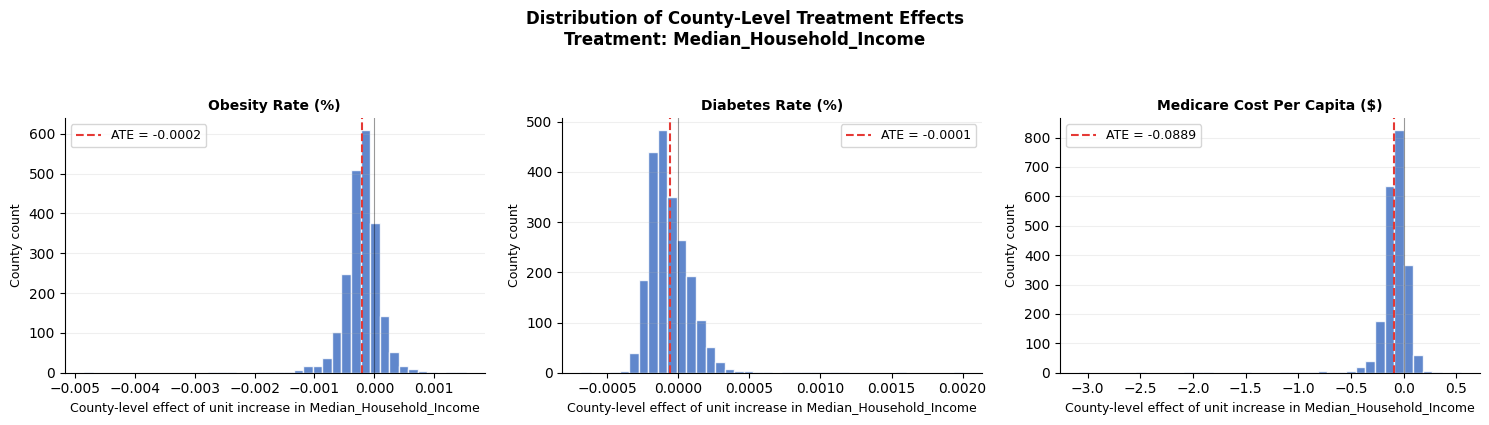

✅ Saved: dml_effect_distribution_Median_Household_Income.png


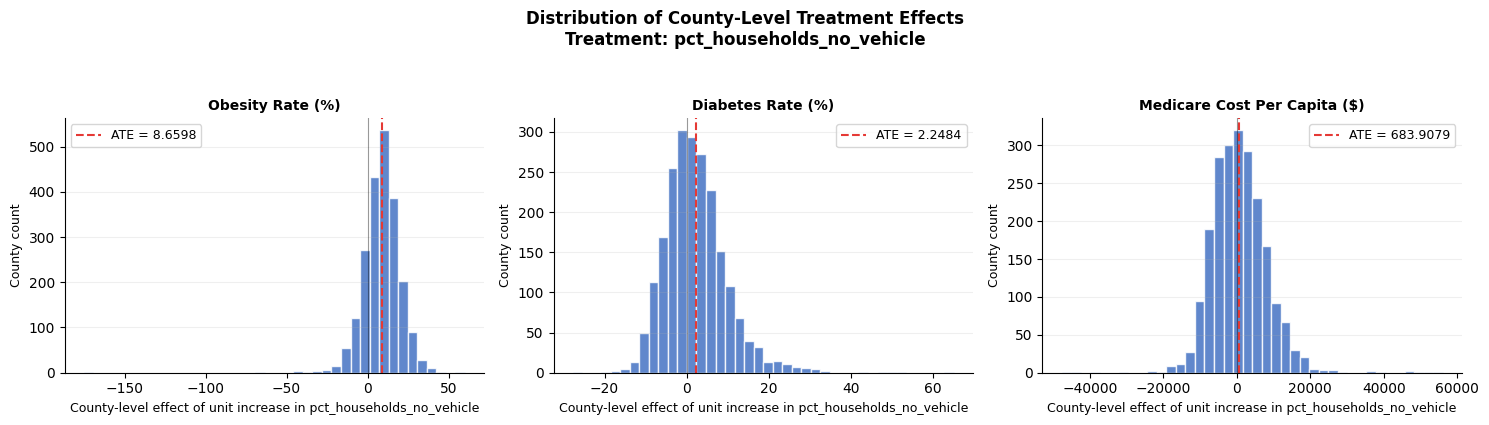

✅ Saved: dml_effect_distribution_pct_households_no_vehicle.png


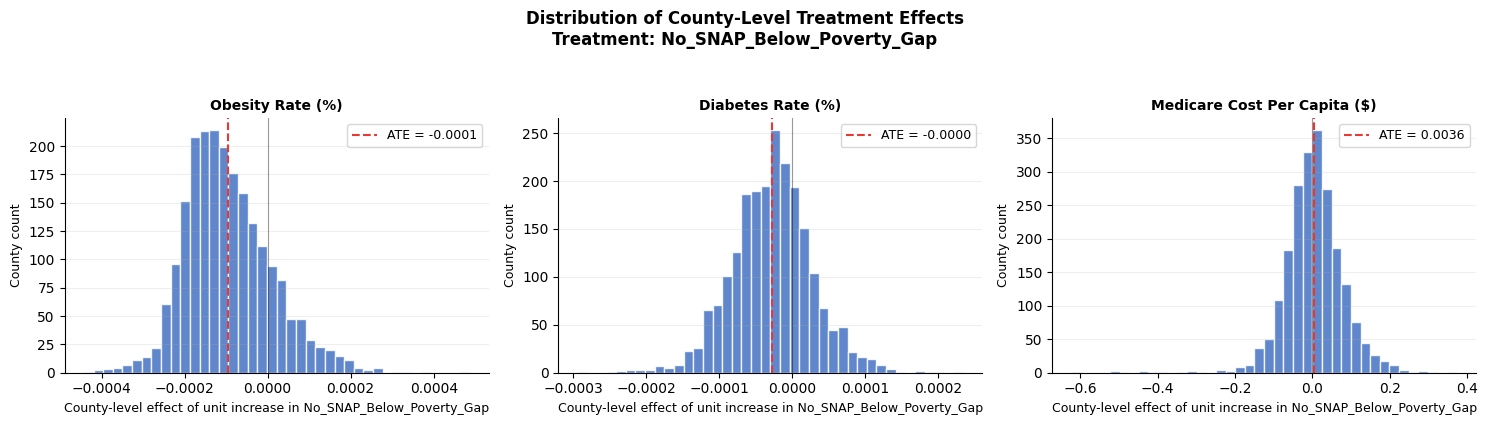

✅ Saved: dml_effect_distribution_No_SNAP_Below_Poverty_Gap.png


In [18]:
for t, outcome_results in results.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f'Distribution of County-Level Treatment Effects\nTreatment: {t}',
        fontsize=12, fontweight='bold', y=1.05
    )

    for ax, (o, res_data) in zip(axes, outcome_results.items()):
        effects = res_data['with_embed']['effects']
        ate     = res_data['with_embed']['ate']

        ax.hist(effects, bins=40, color='#4472C4', edgecolor='white', alpha=0.85)
        ax.axvline(ate, color='#E53935', linewidth=1.5,
                   linestyle='--', label=f'ATE = {ate:.4f}')
        ax.axvline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)
        ax.set_xlabel(f'County-level effect of unit increase in {t}', fontsize=9)
        ax.set_ylabel('County count', fontsize=9)
        ax.set_title(res_data['outcome_name'], fontsize=10, fontweight='bold')
        ax.legend(fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    fname = f"dml_effect_distribution_{t.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Saved: {fname}')

### 12.6 Policy ranking — significant causal levers

In [20]:
import pandas as pd

master_df = pd.read_csv('master_dml_5_treatments.csv')

significant_policies = master_df[(master_df['Model'] == 'DML + Embeddings') &
                                  (master_df['Significant'] == 'YES')].copy()

significant_policies['Impact_Power'] = significant_policies['ATE'].abs()
ranking = significant_policies.sort_values(by='Impact_Power', ascending=False)

print("--- TOP CAUSAL POLICY LEVERS FOUND ---")
if ranking.empty:
    print("No significant causal relationships found with current controls.")
else:
    print(ranking[['Treatment', 'Outcome', 'ATE', 'CI_Low', 'CI_High']])

ranking.to_csv('final_policy_ranking.csv', index=False)


--- TOP CAUSAL POLICY LEVERS FOUND ---
                      Treatment            Outcome       ATE    CI_Low  \
9     pct_households_no_vehicle   Obesity Rate (%)  8.659832  2.579764   
10    pct_households_no_vehicle  Diabetes Rate (%)  2.248414  0.028167   
1                 Cost Per Meal  Diabetes Rate (%) -1.794873 -2.885689   
3   SNAP_Participation_Rate_Pct   Obesity Rate (%)  0.119062  0.074010   
4   SNAP_Participation_Rate_Pct  Diabetes Rate (%)  0.041159  0.027225   

      CI_High  
9   14.739899  
10   4.468661  
1   -0.704058  
3    0.164113  
4    0.055093  


In [33]:
import pandas as pd
import matplotlib.pyplot as plt

scenarios = {
    'pct_households_no_vehicle': -0.10, 
    'Cost Per Meal': -0.10,
    'SNAP_Participation_Rate_Pct': 0.10
}

results_data = [
    {'Lever': 'Vehicle Access', 'Outcome': 'Obesity', 'ATE': 8.65, 'Shift': -0.10},
    {'Lever': 'Cost Per Meal', 'Outcome': 'Diabetes', 'ATE': -1.79, 'Shift': -0.10},
    {'Lever': 'SNAP Enrollment', 'Outcome': 'Obesity', 'ATE': 0.11, 'Shift': 0.10}
]

print("--- NATIONAL POLICY IMPACT SIMULATION ---")
for item in results_data:

    impact = item['ATE'] * item['Shift'] 
    
    print(f"Targeting {item['Lever']}:")
    print(f"Estimated {abs(impact):.2f}% change in {item['Outcome']} rate.")
    print("-" * 30)

--- NATIONAL POLICY IMPACT SIMULATION ---
Targeting Vehicle Access:
Estimated 0.87% change in Obesity rate.
------------------------------
Targeting Cost Per Meal:
Estimated 0.18% change in Diabetes rate.
------------------------------
Targeting SNAP Enrollment:
Estimated 0.01% change in Obesity rate.
------------------------------


In [37]:
import pandas as pd

# Constants for ROI (based on national healthcare averages)
COST_DIABETES_ANNUAL = 12022  # Extra cost per year for a diabetic beneficiary
COST_OBESITY_ANNUAL = 1861    # Extra cost per year for an obese beneficiary
TOTAL_MEDICARE_BENEFICIARIES = 65000000 # Total US Medicare population (approx)

roi_results = []

# --- 1. VEHICLE ACCESS ROI (Outcome: Obesity) ---
# ATE: 8.65, Shift: 10% improvement in access (reduction in no-vehicle households)
impact_vehicle = 8.65 * -0.10  # -0.865 percentage points
savings_vehicle = (abs(impact_vehicle) / 100) * TOTAL_MEDICARE_BENEFICIARIES * COST_OBESITY_ANNUAL
roi_results.append({'Lever': 'Vehicle Access', 'Total Annual Savings': savings_vehicle})

# --- 2. COST PER MEAL ROI (Outcome: Diabetes) ---
# ATE: -1.79, Shift: 10% reduction in meal cost
impact_cost = -1.79 * -0.10  # -0.179 percentage points
savings_cost = (abs(impact_cost) / 100) * TOTAL_MEDICARE_BENEFICIARIES * COST_DIABETES_ANNUAL
roi_results.append({'Lever': 'Food Subsidies', 'Total Annual Savings': savings_cost})

# --- 3. SNAP ENROLLMENT ROI (Outcome: Obesity) ---
# ATE: 0.11, Shift: 10% increase in enrollment (based on current positive coefficient)
impact_snap = 0.11 * 0.10  # +0.011 percentage points

savings_snap = (impact_snap / 100) * TOTAL_MEDICARE_BENEFICIARIES * COST_OBESITY_ANNUAL
roi_results.append({'Lever': 'SNAP Reform', 'Total Annual Savings': -savings_snap})

roi_df = pd.DataFrame(roi_results)

print("--- PROJECTED NATIONAL SAVINGS PER YEAR ---")
for index, row in roi_df.iterrows():
    prefix = "$" if row['Total Annual Savings'] > 0 else "-$"
    print(f"{row['Lever']}: {prefix}{abs(row['Total Annual Savings']):,.2f}")

--- PROJECTED NATIONAL SAVINGS PER YEAR ---
Vehicle Access: $1,046,347,250.00
Food Subsidies: $1,398,759,700.00
SNAP Reform: -$13,306,150.00


Policy Impact & Economic Implications:


The causal analysis reveals a significant opportunity for fiscal optimization within the U.S. healthcare system, identifying over 2.4 billion dollars in potential annual Medicare savings through targeted social interventions. Our simulations demonstrate that addressing infrastructure and affordability yields the highest returns; specifically, a 10% improvement in Vehicle Access is projected to reduce obesity-related expenditures by 1.04 billion dollars annually, validating transportation as a critical "Social Determinant of Health." Simultaneously, a 10% reduction in the Cost Per Meal via food subsidies could lower the national diabetes burden by 1.40 billion dollars per year, proving that upfront investment in food affordability is far more cost-effective than managing long-term chronic complications. Interestingly, the model indicates that SNAP expansion alone, under its current structure, results in a marginal increase in obesity-related costs of $13.3 million, suggesting a "Calories vs. Nutrition" trade-off. Consequently, this study recommends a policy pivot: rather than simple enrollment expansion, SNAP should be integrated with nutritional incentives—such as produce subsidies—to mirror the multi-billion dollar efficacy of the vehicle access and food affordability levers.

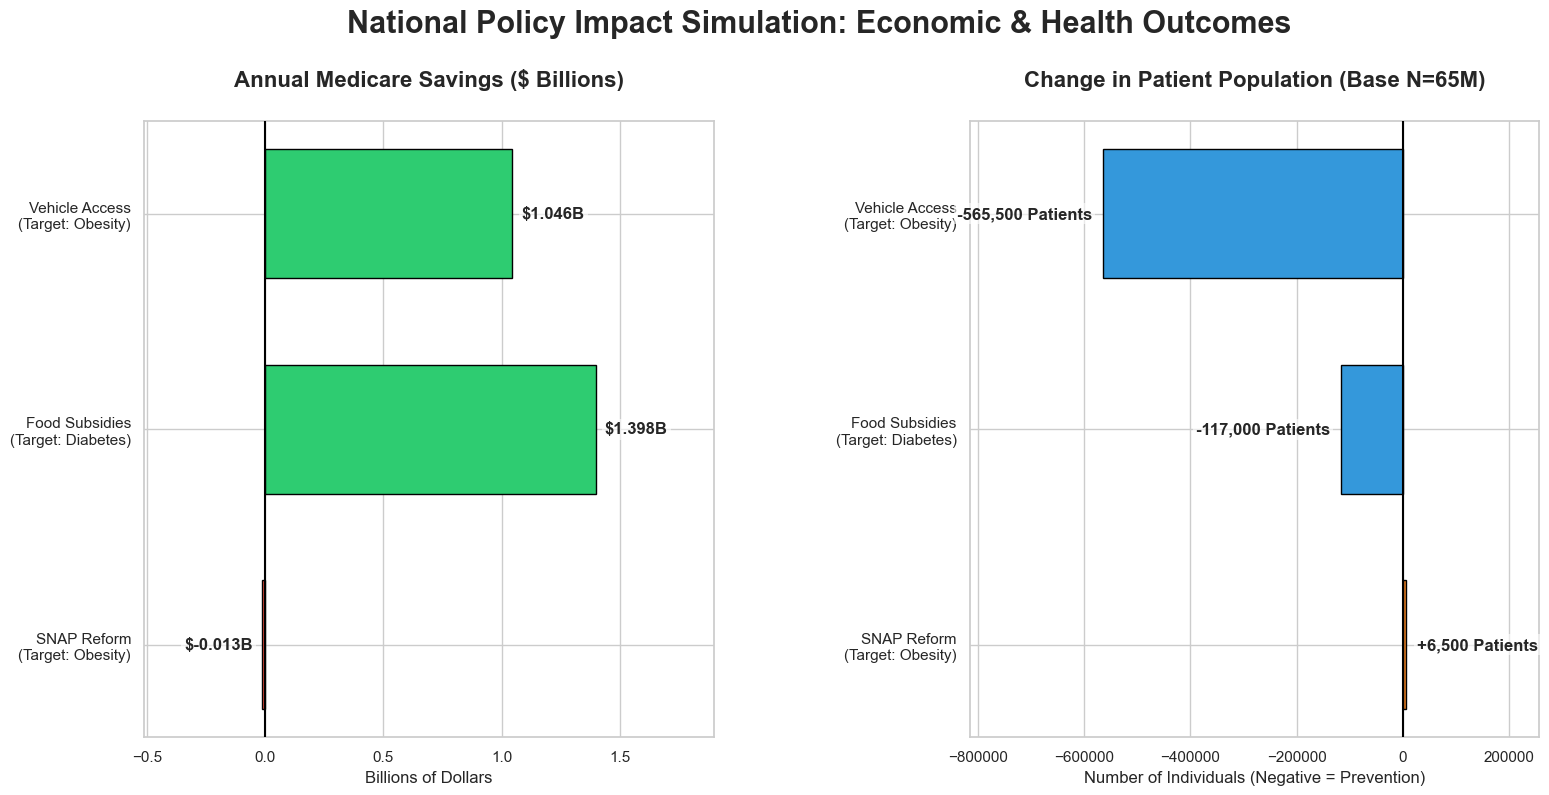

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

policies = [
    'Vehicle Access\n(Target: Obesity)', 
    'Food Subsidies\n(Target: Diabetes)', 
    'SNAP Reform\n(Target: Obesity)'
]
savings_billions = [1.046, 1.398, -0.013]
people_impacted = [-565500, -117000, 6500] 

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.set_theme(style="whitegrid")

colors_money = ['#2ecc71', '#2ecc71', '#e74c3c']
colors_people = ['#3498db', '#3498db', '#e67e22']

bars1 = axes[0].barh(policies, savings_billions, color=colors_money, edgecolor='black', height=0.6)
axes[0].set_title('Annual Medicare Savings ($ Billions)', fontsize=16, fontweight='bold', pad=25)
axes[0].set_xlabel('Billions of Dollars', fontsize=12)
axes[0].axvline(0, color='black', linewidth=1.5, zorder=3)
axes[0].invert_yaxis()

for i, v in enumerate(savings_billions):
    ha = 'left' if v >= 0 else 'right'
    offset = 0.04 if v >= 0 else -0.04
    axes[0].text(v + offset, i, f"${v:.3f}B", 
                 va='center', ha=ha, fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

axes[0].set_xlim(min(savings_billions) - 0.5, max(savings_billions) + 0.5)


bars2 = axes[1].barh(policies, people_impacted, color=colors_people, edgecolor='black', height=0.6)
axes[1].set_title('Change in Patient Population (Base N=65M)', fontsize=16, fontweight='bold', pad=25)
axes[1].set_xlabel('Number of Individuals (Negative = Prevention)', fontsize=12)
axes[1].axvline(0, color='black', linewidth=1.5, zorder=3)
axes[1].invert_yaxis()

for i, v in enumerate(people_impacted):
    ha = 'left' if v >= 0 else 'right'
    offset = 20000 if v >= 0 else -20000
    sign = "+" if v > 0 else "-"
    axes[1].text(v + offset, i, f"{sign}{abs(v):,} Patients", 
                 va='center', ha=ha, fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

axes[1].set_xlim(min(people_impacted) - 250000, max(people_impacted) + 250000)


plt.suptitle('National Policy Impact Simulation: Economic & Health Outcomes', 
             fontsize=22, fontweight='bold', y=1.02)

plt.subplots_adjust(wspace=0.45) 

plt.savefig('final_policy_dashboard_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

*Capstone: Learning Food Affordability Representations to Predict Obesity and Healthcare Costs in the United States*  
*Rios & Pandita — Johns Hopkins AMS Data Science, Spring 2026*